# **Stochastic Gradient Descent**

### **Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

### **Load Dataset**

In [2]:
X, y = load_diabetes(return_X_y=True)

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (442, 10)
Target shape: (442,)


### **Train-Test Split**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

- Training data → used to train the model 
- Testing data → used to evaluate model performance.

#### **Baseline Model (Linear Regression)**

In [4]:
reg = LinearRegression()
reg.fit(X_train, y_train)

print("Coefficients:", reg.coef_)
print("Intercept:", reg.intercept_)

Coefficients: [  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
Intercept: 151.88331005254167


In [5]:
y_pred = reg.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.439933866156897


- Unlike Batch Gradient Descent, Stochastic Gradient Descent updates
the model parameters using **one random sample at a time**.

### **Advantages:**

• Faster updates  
• Works well for large datasets  
• Can escape shallow local minima

### **Disadvantage:**

• Updates are noisy, so convergence may fluctuate.

# **Using Scikit-learn SGDRegressor**

In [16]:
from sklearn.linear_model import SGDRegressor

reg = SGDRegressor(
    max_iter=1000,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)

reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.44411870462940406


## **Visualization of SGD Learning**

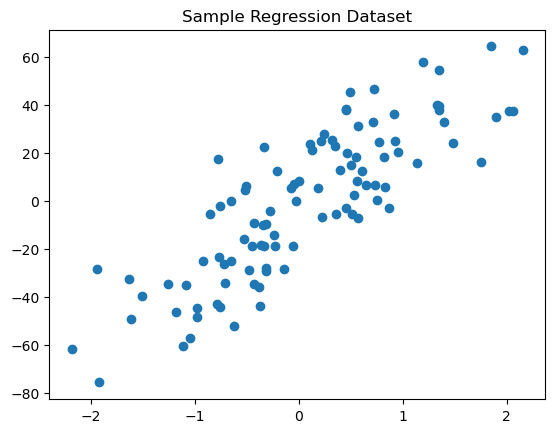

In [6]:
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=13
)

plt.scatter(X, y)
plt.title("Sample Regression Dataset")
plt.show()

# **Animation of SGD Learning**

In [7]:
from matplotlib.animation import FuncAnimation

b = 150
m = -127.82

all_b = []
all_m = []

epochs = 1

for i in range(epochs):
    for j in range(X.shape[0]):

        idx = np.random.randint(X.shape[0])

        slope_b = -2 * (y[idx] - (m * X[idx]) - b)
        slope_m = -2 * (y[idx] - (m * X[idx]) - b) * X[idx]

        lr = 0.01

        b = b - lr * slope_b
        m = m - lr * slope_m

        all_b.append(b)
        all_m.append(m)

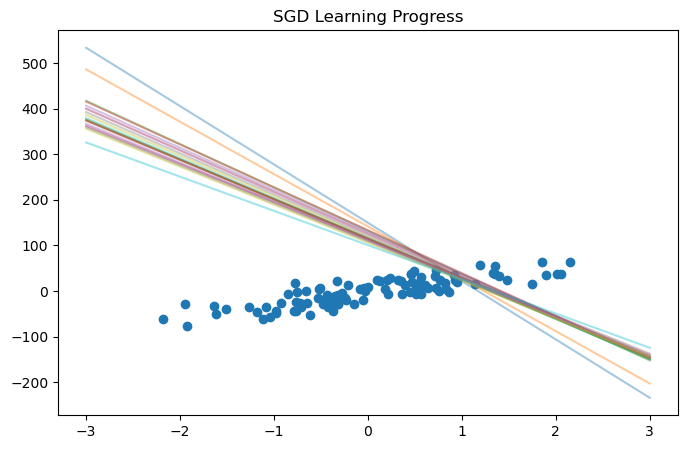

In [8]:
fig, ax = plt.subplots(figsize=(8,5))

x_line = np.linspace(-3,3,100)

ax.scatter(X,y)

for i in range(20):
    ax.plot(x_line, all_m[i]*x_line + all_b[i], alpha=0.4)

plt.title("SGD Learning Progress")
plt.show()

- The plotted lines show how the regression model improves during stochastic gradient descent.
- Initially the line is far from the data.
- As SGD updates parameters using random samples,the line gradually moves toward the optimal solution.
- Because updates use individual samples, the path to convergence is noisy but computationally efficient.

### **Loss vs Iterations (Training Error Curve)**

In [9]:
loss_history = []

b = 150
m = -127.82

learning_rate = 0.01
epochs = 1

for i in range(epochs):
    for j in range(X.shape[0]):

        idx = np.random.randint(X.shape[0])

        y_pred = m * X[idx] + b

        loss = (y[idx] - y_pred) ** 2
        loss_history.append(loss)

        slope_b = -2 * (y[idx] - y_pred)
        slope_m = -2 * (y[idx] - y_pred) * X[idx]

        b = b - learning_rate * slope_b
        m = m - learning_rate * slope_m

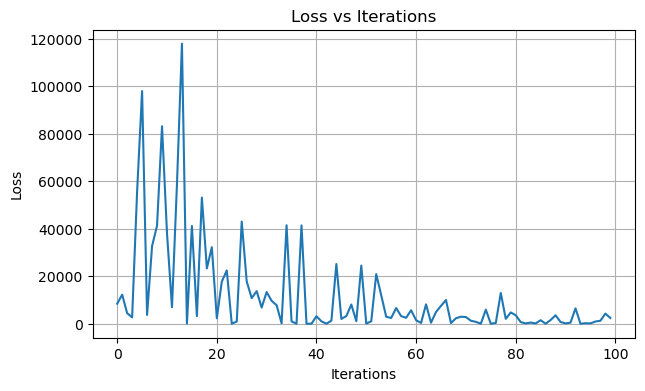

In [10]:
plt.figure(figsize=(7,4))

plt.plot(loss_history)

plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.grid()
plt.show()

- initially the loss is high because the model parameters are far from the optimal values.
As SGD updates the parameters using random samples, the loss gradually decreases

## **Parameter Convergence Graph**
- This shows how the parameters m (slope) and b (intercept) change during training.

In [11]:
m_history = []
b_history = []

b = 150
m = -127.82

learning_rate = 0.01

for i in range(100):

    idx = np.random.randint(X.shape[0])

    y_pred = m * X[idx] + b

    slope_b = -2 * (y[idx] - y_pred)
    slope_m = -2 * (y[idx] - y_pred) * X[idx]

    b = b - learning_rate * slope_b
    m = m - learning_rate * slope_m

    m_history.append(m)
    b_history.append(b)

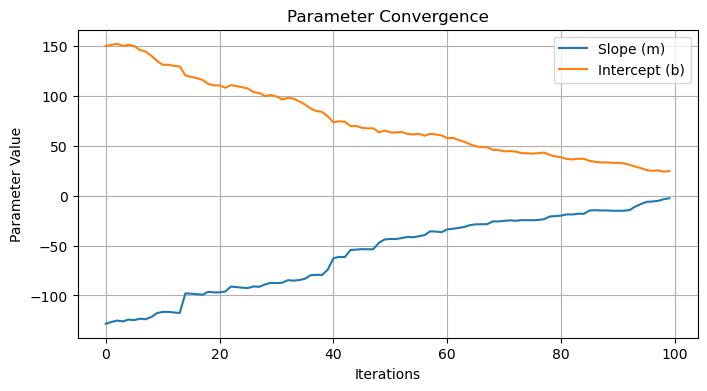

In [12]:
plt.figure(figsize=(8,4))

plt.plot(m_history, label="Slope (m)")
plt.plot(b_history, label="Intercept (b)")

plt.title("Parameter Convergence")
plt.xlabel("Iterations")
plt.ylabel("Parameter Value")

plt.legend()
plt.grid()

plt.show()

### **Cost Surface Contour with Optimization Path**

In [14]:
m_vals = np.linspace(-150,150,50)
b_vals = np.linspace(-150,150,50)

m_grid, b_grid = np.meshgrid(m_vals,b_vals)

cost = np.zeros(m_grid.shape)

for i in range(m_grid.shape[0]):
    for j in range(m_grid.shape[1]):
        y_pred = m_grid[i,j]*X.reshape(-1) + b_grid[i,j]
        cost[i,j] = np.mean((y - y_pred)**2)

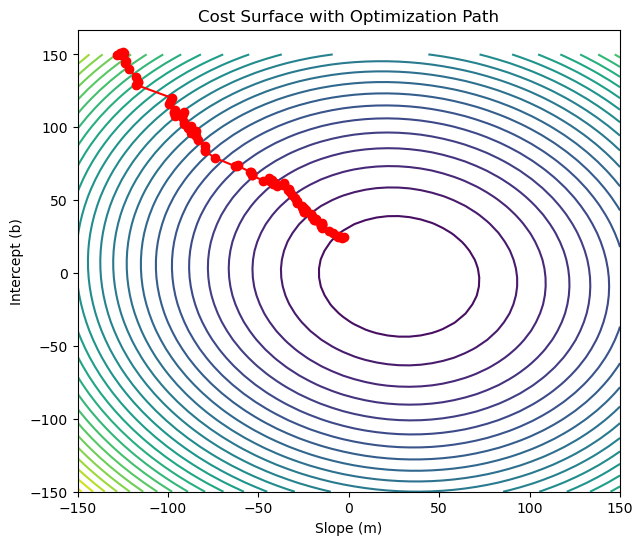

In [15]:
plt.figure(figsize=(7,6))

plt.contour(m_grid, b_grid, cost, levels=30)

plt.plot(m_history, b_history, color='red', marker='o')

plt.title("Cost Surface with Optimization Path")
plt.xlabel("Slope (m)")
plt.ylabel("Intercept (b)")

plt.show()

- The contour plot represents the cost function surface for different values of slope and intercept.
- Each contour line represents a region with equal error.
- The red path shows how Stochastic Gradient Descent updates the parameters during training.
- The algorithm gradually moves toward the region with the lowest cost, which represents the optimal model parameters.

### **PLot 3D Graph**

In [17]:
m_vals = np.linspace(-150,150,50)
b_vals = np.linspace(-150,150,50)

m_grid, b_grid = np.meshgrid(m_vals,b_vals)

cost_surface = np.zeros(m_grid.shape)

In [18]:
for i in range(m_grid.shape[0]):
    for j in range(m_grid.shape[1]):
        
        y_pred = m_grid[i,j]*X.reshape(-1) + b_grid[i,j]
        
        cost_surface[i,j] = np.mean((y - y_pred)**2)

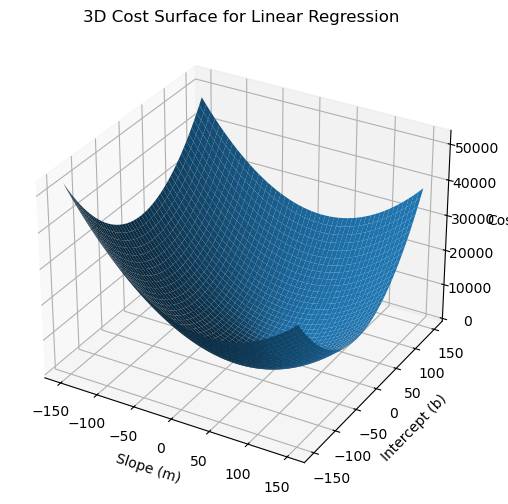

In [19]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,6))

ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(m_grid, b_grid, cost_surface)

ax.set_xlabel("Slope (m)")
ax.set_ylabel("Intercept (b)")
ax.set_zlabel("Cost")

plt.title("3D Cost Surface for Linear Regression")

plt.show()